<a href="https://colab.research.google.com/github/IT24100378/ToxicCommentNLPfinal/blob/Lowercasing/Lowercasing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Load dataset
df = pd.read_csv("/content/train.csv")


# Show dataset info and first 5 rows
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            159571 non-null  object
 1   comment_text  159571 non-null  object
 2   toxic         159571 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.7+ MB
None

First 5 Rows:
                 id                                       comment_text  toxic
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0



Before Preprocessing Dataset Summary:
          char_count     word_count
count  159571.000000  159571.000000
mean      394.138666      67.272462
std       590.725497      99.231392
min         5.000000       1.000000
25%        96.000000      17.000000
50%       205.000000      36.000000
75%       436.000000      75.000000
max      5000.000000    1411.000000


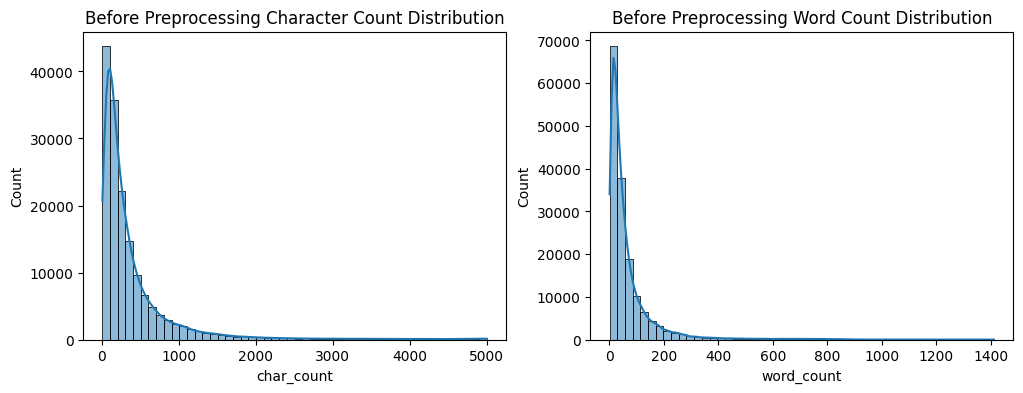

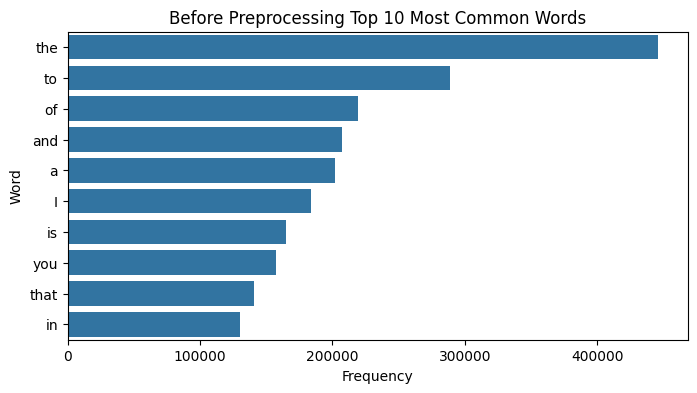

In [2]:
# Function for EDA
def text_eda(data, column_name, title_prefix=""):
    # Add text length features
    data["char_count"] = data[column_name].apply(len)
    data["word_count"] = data[column_name].apply(lambda x: len(str(x).split()))

    # Summary statistics
    print(f"\n{title_prefix} Dataset Summary:")
    print(data[[column_name, "char_count", "word_count"]].describe())

    # Distribution plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data["char_count"], bins=50, ax=axes[0], kde=True)
    axes[0].set_title(f"{title_prefix} Character Count Distribution")
    sns.histplot(data["word_count"], bins=50, ax=axes[1], kde=True)
    axes[1].set_title(f"{title_prefix} Word Count Distribution")
    plt.show()

    # Most common words
    all_words = " ".join(data[column_name].astype(str)).split()
    common_words = Counter(all_words).most_common(10)
    common_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

    plt.figure(figsize=(8,4))
    sns.barplot(x="Frequency", y="Word", data=common_df)
    plt.title(f"{title_prefix} Top 10 Most Common Words")
    plt.show()

 # ----- EDA Before Preprocessing -----
text_eda(df.copy(), "comment_text", title_prefix="Before Preprocessing")

In [3]:
# ----- Preprocessing (Lowercasing) -----
df_preprocessed = df.copy()
df_preprocessed["comment_text"] = df_preprocessed["comment_text"].str.lower()
print("✅ Data has been preprocessed: all text converted to lowercase.")

✅ Data has been preprocessed: all text converted to lowercase.



After Preprocessing Dataset Summary:
          char_count     word_count
count  159571.000000  159571.000000
mean      394.138835      67.272462
std       590.726268      99.231392
min         5.000000       1.000000
25%        96.000000      17.000000
50%       205.000000      36.000000
75%       436.000000      75.000000
max      5000.000000    1411.000000


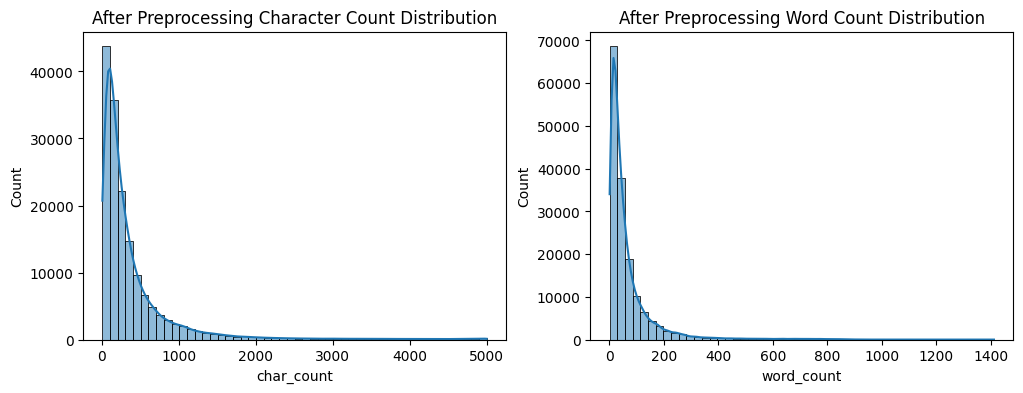

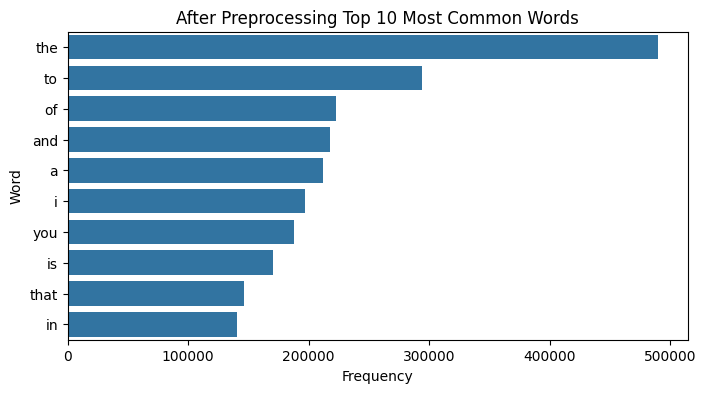

In [4]:
# ----- EDA After Preprocessing -----
text_eda(df_preprocessed.copy(), "comment_text", title_prefix="After Preprocessing")

In [5]:
from collections import Counter

# ----- Compare Top Words Before vs After Preprocessing -----
def compare_top_words(df_original, df_preprocessed, column="comment_text", top_n=10):
    # Top words before
    words_before = " ".join(df_original[column].astype(str)).split()
    common_before = Counter(words_before).most_common(top_n)

    # Top words after
    words_after = " ".join(df_preprocessed[column].astype(str)).split()
    common_after = Counter(words_after).most_common(top_n)

    # Combine into a DataFrame for side-by-side view
    comparison_df = pd.DataFrame({
        "Before Preprocessing": [w for w, _ in common_before],
        "Freq Before": [c for _, c in common_before],
        "After Preprocessing": [w for w, _ in common_after],
        "Freq After": [c for _, c in common_after]
    })

    print("\n🔎 Top 10 Most Common Words Before vs After Lowercasing:\n")
    print(comparison_df)

# Run comparison
compare_top_words(df, df_preprocessed)



🔎 Top 10 Most Common Words Before vs After Lowercasing:

  Before Preprocessing  Freq Before After Preprocessing  Freq After
0                  the       445991                 the      490030
1                   to       288818                  to      294069
2                   of       219335                  of      222834
3                  and       207381                 and      218120
4                    a       201821                   a      211778
5                    I       183946                   i      196694
6                   is       164640                 you      187782
7                  you       157282                  is      170753
8                 that       140545                that      146478
9                   in       130262                  in      140540


In [6]:
# ----- Save Preprocessed Dataset -----
df_preprocessed.to_csv("train_preprocessed_lowercased.csv", index=False)

